<a href="https://colab.research.google.com/github/ManideepLadi/cs6910_assignment3/blob/manideep/attention_part2_adding_connectivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving attention.py to attention.py


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import seaborn as sns
#from rich.progress import track

import tensorflow as tf
from tensorflow import keras
import keras.backend as K
from tensorflow.keras import layers
from keras.utils.vis_utils import plot_model

from keras.layers.embeddings import Embedding
from keras.layers import Input,Dense,LSTM,GRU,RNN,SimpleRNN,Softmax,Dropout,Concatenate
from keras.layers import TimeDistributed
from keras.callbacks import Callback

from keras import Model
from attention import AttentionLayer

from math import log
import math

<h2>1.Get the train, val and test Data</h2>

In [ ]:
!wget https://storage.googleapis.com/gresearch/dakshina/dakshina_dataset_v1.0.tar
!tar -xvf '/content/dakshina_dataset_v1.0.tar'

--2021-05-21 17:29:43--  https://storage.googleapis.com/gresearch/dakshina/dakshina_dataset_v1.0.tar
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.194.128, 173.194.197.128, 64.233.191.128, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.194.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2008340480 (1.9G) [application/x-tar]
Saving to: ‘dakshina_dataset_v1.0.tar’

dakshina_dataset_v1 100%[===================>]   1.87G  16.2MB/s    in 23s     

2021-05-21 17:30:06 (82.0 MB/s) - ‘dakshina_dataset_v1.0.tar’ saved [2008340480/2008340480]

dakshina_dataset_v1.0/bn/
dakshina_dataset_v1.0/bn/lexicons/
dakshina_dataset_v1.0/bn/lexicons/bn.translit.sampled.test.tsv
dakshina_dataset_v1.0/bn/lexicons/bn.translit.sampled.train.tsv
dakshina_dataset_v1.0/bn/lexicons/bn.translit.sampled.dev.tsv
dakshina_dataset_v1.0/bn/native_script_wikipedia/
dakshina_dataset_v1.0/bn/native_script_wikipedia/bn.wiki-filt.valid.text.shuf.tx

In [ ]:
train = '/content/dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.train.tsv'
val =   '/content/dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.dev.tsv'
test =  '/content/dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.test.tsv'

<h2>2 Preprocessing</h2>

In [ ]:
class Preprocess:

  def __init__(self):

    self.num_encoder_tokens = None
    self.num_decoder_tokens = None
    self.input_token_index = None
    self.target_token_index = None
    self.reverse_input_char_index = None
    self.reverse_target_char_index = None
    self.max_encoder_seq_length = None
    self.max_decoder_seq_length = None

    return


  def extract_train(self,path):

    input_texts = []
    target_texts = []
    input_characters = set()
    target_characters = set()
    with open(path, "r", encoding="utf-8") as f:
        lines = f.read().split("\n")
    for line in lines[: len(lines) - 1]:
      target_text,input_text, attestation = line.split("\t")
      # We use "tab" as the "start sequence" character
      # for the targets, and "\n" as "end sequence" character.
      target_text = "\t" + target_text + "\n"
      input_texts.append(input_text)
      target_texts.append(target_text)
      for char in input_text:
        if char not in input_characters:
          input_characters.add(char)
      for char in target_text:
        if char not in target_characters:
          target_characters.add(char)

    input_characters = sorted(list(input_characters))
    target_characters = sorted(list(target_characters))
    self.num_encoder_tokens = len(input_characters)
    self.num_decoder_tokens = len(target_characters)
    self.max_encoder_seq_length = max([len(txt) for txt in input_texts])
    self.max_decoder_seq_length = max([len(txt) for txt in target_texts])
    self.input_token_index = dict([(char, i) for i, char in enumerate(input_characters)])
    self.target_token_index = dict([(char, i) for i, char in enumerate(target_characters)])

    self.reverse_input_char_index = dict((i, char) for char, i in self.input_token_index.items())
    self.reverse_target_char_index = dict((i, char) for char, i in self.target_token_index.items())

    return

  def vectorize_(self,path):
    input_texts = []
    target_texts = []
    
    with open(path, "r", encoding="utf-8") as f:
      lines = f.read().split("\n")
    for line in lines[: len(lines) - 1]:
      target_text,input_text, attestation = line.split("\t")
      target_text = "\t" + target_text + "\n"
      input_texts.append(input_text)
      target_texts.append(target_text)
      
      
    encoder_input_data = np.zeros((len(input_texts), self.max_encoder_seq_length), dtype="float32")
    decoder_input_data = np.zeros((len(input_texts), self.max_decoder_seq_length), dtype="float32")
    decoder_target_data = np.zeros((len(input_texts), self.max_decoder_seq_length, self.num_decoder_tokens), dtype="float32")

    
    for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
      for t, char in enumerate(input_text):
        encoder_input_data[i][t] = self.input_token_index[char]
      for t, char in enumerate(target_text):
        decoder_input_data[i][t] = self.target_token_index[char]
        if t > 0:
          decoder_target_data[i, t - 1, self.target_token_index[char]] = 1.0
    
    return (input_texts ,target_texts ,encoder_input_data,decoder_input_data,decoder_target_data)

  def print_features(self):

    print("Number of unique input tokens:", self.num_encoder_tokens)
    print("Number of unique output tokens:", self.num_decoder_tokens)
    print("Max sequence length for inputs:", self.max_encoder_seq_length)
    print("Max sequence length for outputs:", self.max_decoder_seq_length)

    return

<h4>2.1 extract features from train data</h4>

In [ ]:
pr_obj=Preprocess()
pr_obj.extract_train(train)
pr_obj.print_features()

Number of unique input tokens: 26
Number of unique output tokens: 65
Max sequence length for inputs: 20
Max sequence length for outputs: 21


<h4>2.2 Vectorize the train,val,test data</h4>

In [ ]:
en_ip_tr_text ,de_ip_tr_text , en_ip_tr_data , de_ip_tr_data , de_op_tr_data  = pr_obj.vectorize_(train)
en_ip_val_text ,de_ip_val_text , en_ip_val_data , de_ip_val_data , de_op_val_data  = pr_obj.vectorize_(val)
en_ip_ts_text ,de_ip_ts_text , en_ip_ts_data , de_ip_ts_data , de_op_ts_data  = pr_obj.vectorize_(test)

print("Train data shape : ",en_ip_tr_data.shape)
print("Validation data shape : ",en_ip_val_data.shape)
print("Test data shape : ",en_ip_ts_data.shape)

Train data shape :  (44204, 20)
Validation data shape :  (4358, 20)
Test data shape :  (4502, 20)


# <h2>3.Callback for getting word level accuracy of validation data</h2>

In [ ]:
class Utility:
  def beam_search_decoder(self,data, k):
    decodedSequences = [[list(), 0.0]]
    # walk over each step in sequence
    for row in data:
      all_candidates = list()
      # expand each current candidate
      for i in range(len(decodedSequences)):
        seq, score = decodedSequences[i]
        for j in range(len(row)):
          candidate = [seq + [j], score - log(row[j])]
          all_candidates.append(candidate)
      # order all candidates by score
      ordered = sorted(all_candidates, key=lambda tup:tup[1])
      # select k best
      decodedSequences = ordered[:k]
    return decodedSequences
  
  def decode_translate(self,seq,pr_obj):
    decoded_sentence = [] 
    for x in seq:
      sampled_char = pr_obj.reverse_target_char_index[x]
      decoded_sentence.append(sampled_char)
    return "".join(decoded_sentence)
  

In [ ]:
class WordAccuracyCallback(keras.callbacks.Callback):
  def __init__(self,beam_size,pr_obj):
    self.beam_size=beam_size
    self.pr_obj=pr_obj
  def on_epoch_end(self, epoch, logs=None):
    yPred=self.model.predict([en_ip_val_data,de_ip_val_data])
    count=0
    U=Utility()
    k=self.beam_size
    for i in range(yPred.shape[0]):
      predictedSequences=U.beam_search_decoder(yPred[i],k)
      for j in range(k):
        if "\t"+U.decode_translate(predictedSequences[j][0][:len(de_ip_val_text[i])-1],self.pr_obj)==de_ip_val_text[i]:
          count=count+1
          break
    factor = 10.0 ** 4
    logs["WordAccuracy"]=math.trunc((count/yPred.shape[0])*factor)/factor
    print("- wordAccuracy:",logs["WordAccuracy"])

<h2>4.Model Class</h2>

In [ ]:
class RNN_Model:

  def __init__(self,pr_obj,embed_size ,no_of_encoder_layers,no_of_decoder_layers,latent_dimension,dropout,recurrent_dropout,cell_type,beam_size):

    self.pr_obj=pr_obj
    self.embed_size = embed_size
    self.no_of_encoder_layers = no_of_encoder_layers
    self.no_of_decoder_layers = no_of_decoder_layers

    #scalar
    self.latent_dimension = latent_dimension
    self.dropout = dropout
    self.recurrent_dropout=recurrent_dropout
    self.cell_type=cell_type
    self.model = None
    self.beam_size=beam_size

    #used to store all the encoder layers and dec layers..
    self.input_layers = None
    self.output_layers = None

    #the inference model..
    self.encoder_model = None
    self.decoder_model = None

  def BUILD_MODEL(self,max_encoder_seq_length,num_encoder_tokens,max_decoder_seq_length,num_decoder_tokens):

    #Define the encoder Model..
    encoder_inputs = Input(shape=(max_encoder_seq_length,))
    embd_enc_ip = Embedding(input_dim = num_encoder_tokens,output_dim = self.embed_size ,
                            input_length=max_encoder_seq_length ,name='enc_embd_layer')(encoder_inputs)

    outputs = embd_enc_ip
    encoder_states = []
    self.input_layers = []

    for j in range(self.no_of_encoder_layers):

      if self.cell_type == 'LSTM':
        self.input_layers.append(
            LSTM(self.latent_dimension,return_state=True, return_sequences=True ,recurrent_dropout=self.recurrent_dropout,dropout=self.dropout))
        

      elif self.cell_type == 'GRU':
        self.input_layers.append(
            GRU(self.latent_dimension,return_state=True, return_sequences=True ,recurrent_dropout=self.recurrent_dropout,dropout=self.dropout))

      elif self.cell_type == 'RNN':
        self.input_layers.append(
            SimpleRNN(self.latent_dimension,return_state=True,
                      return_sequences=True ,recurrent_dropout=self.recurrent_dropout,dropout=self.dropout))
        
      all_op = self.input_layers[-1](outputs)
      outputs,encoder_state = all_op[0],all_op[1:]
      encoder_states += [encoder_state]
  
    encoder_outputs=outputs

    #Define The Decoder Model:
    decoder_inputs = Input(shape=(max_decoder_seq_length,))
    embd_dec_ip = Embedding(input_dim = num_decoder_tokens,output_dim = self.embed_size,
                            input_length=max_decoder_seq_length ,name='dec_embd_layer')(decoder_inputs)

    outputs = embd_dec_ip
    self.output_layers = []

    for j in range(self.no_of_decoder_layers):
      if self.cell_type == 'LSTM':
        self.output_layers.append(LSTM(self.latent_dimension,
                                       return_sequences=True, return_state=True ,recurrent_dropout=self.recurrent_dropout,dropout=self.dropout))
      
      elif self.cell_type == 'GRU':
        self.output_layers.append(GRU(self.latent_dimension,
                                       return_sequences=True, return_state=True ,recurrent_dropout=self.recurrent_dropout,dropout=self.dropout))
      
      elif self.cell_type == 'RNN':
        self.output_layers.append(SimpleRNN(self.latent_dimension,
                                       return_sequences=True, return_state=True ,recurrent_dropout=self.recurrent_dropout,dropout=self.dropout))
      
      all_op = self.output_layers[-1](outputs, initial_state = encoder_states[j])
      outputs, dstates = all_op[0],all_op[1:]

    decoder_outputs=outputs

    attn_layer = AttentionLayer(name='attention_layer')
    attn_out, attn_states = attn_layer([encoder_outputs,decoder_outputs])

    decoder_concat_input = Concatenate(axis=-1, name='concat_layer')([decoder_outputs, attn_out])
    dense = Dense(num_decoder_tokens, activation='softmax', name='dense_layer')

    dense_time = TimeDistributed(dense, name='time_distributed_layer')
    decoder_pred = dense_time(decoder_concat_input)

    self.model = keras.Model([encoder_inputs, decoder_inputs], decoder_pred)
    self.model.compile(optimizer='adam',loss='categorical_crossentropy' , metrics=['accuracy'])
    return

  def FIT_RNN(self ,  en_ip_tr_data , de_ip_tr_data , de_op_tr_data,epochs ,
              batch_size):
    self.model.fit(
        [en_ip_tr_data, de_ip_tr_data],
        de_op_tr_data,
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        callbacks = [WordAccuracyCallback(self.beam_size,self.pr_obj)],
        verbose=1)
    return

<h2>5. Inference Class</h2>

In [ ]:
class Inference:

  def __init__(self,parent_model,max_encoder_seq_length,max_decoder_seq_length,target_token_index,
               reverse_target_char_index,latent_dimension,input_layers,output_layers,cell_type,num_layers):

    self.model = parent_model
    self.max_encoder_seq_length = max_encoder_seq_length
    self.max_decoder_seq_length = max_decoder_seq_length
    self.target_token_index = target_token_index
    self.reverse_target_char_index = reverse_target_char_index
    self.latent_dimension = latent_dimension
    self.input_layers = input_layers
    self.output_layers = output_layers
    self.cell_type = cell_type
    self.num_layers = num_layers
    self.encoder_model = None
    self.decoder_model = None


  def build_inference_model(self):

    batch_size = 1

    #Define the Encoder Model..
    encoder_inf_inputs = Input(batch_shape = (batch_size,self.max_encoder_seq_length))
    enc_op  = self.model.get_layer('enc_embd_layer')(encoder_inf_inputs)
    enc_inf_states = []

    #pass this input to each enc layer from the model and get the final op...
    for j in range(self.num_layers):
      all_out = self.input_layers[j](enc_op)
      enc_op = all_out[0]
      enc_state = all_out[1:]
      enc_inf_states+=[enc_state]
    
    #encoder ops for all time steps (for the last enc layer only..)
    encoder_inf_states = Input(batch_shape = (batch_size,self.max_encoder_seq_length,self.latent_dimension))
    #producing 1 finalop from encoder and layers 
    self.encoder_model = Model(encoder_inf_inputs, [enc_op,enc_inf_states])

    #Define the Decoder Model..
    decoder_inf_inputs = Input(batch_shape = (batch_size ,1))
    dec_op = self.model.get_layer('dec_embd_layer')(decoder_inf_inputs)

    dec_init_states = []
    dec_inf_states = []
    num_states = 1
    if self.cell_type == 'LSTM':
      num_states = 2

    for j in range(self.num_layers):
      #attach the ip state of corresponding encoder..
      dec_init_state = [Input(batch_shape=(batch_size,self.latent_dimension)) for _ in range(num_states)]

      all_out = self.output_layers[j](dec_op , initial_state = dec_init_state)
      dec_op = all_out[0] 
      dec_inf_state = all_out[1:]

      dec_init_states+= [dec_init_state]
      dec_inf_states+=[dec_inf_state]

    
    #apply attention layer to the last decoder layer op and last encoderlayer op...
    attn_inf_out, attn_inf_states = self.model.get_layer('attention_layer')([encoder_inf_states, dec_op])

    #concatenate att_out and dec_out..
    decoder_inf_concat = Concatenate(axis = -1,name='concat')([dec_op , attn_inf_out])

    #dense_layer = self.model.get_layer('dense_layer')
    decoder_inf_pred = self.model.get_layer('time_distributed_layer')(decoder_inf_concat)

    self.decoder_model = Model(inputs = [encoder_inf_states,dec_init_states,decoder_inf_inputs],
                      outputs = [decoder_inf_pred,attn_inf_states,dec_inf_states])
    
    return 

  #function will return the decoded seq and attention matrix for a given word..
  def decode_sequence(self,input_seq):
    # Encode the input as state vectors.
    enc_op , states_value = self.encoder_model.predict(input_seq)
    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1, 1))
    # Populate the first character of target sequence with the start character rank.
    target_seq[0][0] = self.target_token_index['\t']

    # Sampling loop for a batch of sequences
    # (to simplify, here we assume a batch of size 1).
    stop_condition = False
    decoded_sentence = []  #Creating a list then using "".join() is usually much faster for string creation
    att_mtx = []
    
    while not stop_condition:

      to_split = self.decoder_model.predict([enc_op,states_value,target_seq])

      output_tokens, att_weights, states_value = to_split[0], to_split[1], to_split[2]

      # Sample a token
      sampled_token_index = np.argmax(output_tokens[0, 0])
      sampled_char = self.reverse_target_char_index[sampled_token_index]
      decoded_sentence.append(sampled_char)

      #collect the attention weights
      att_mtx.append(att_weights)
      # Exit condition: either hit max length
      # or find stop character.
      if sampled_char == '\n' or len(decoded_sentence) > self.max_decoder_seq_length:
          stop_condition = True

      # Update the target sequence (of length 1).
      target_seq[0][0] = sampled_token_index
      
    
    return ("".join(decoded_sentence),decoded_sentence,att_mtx)

  #given test data returns the predictions made by the model..
  def get_predictions(self,ip_data,op_text):

    n=len(ip_data)
    predictions = []
    num_correct = 0

    for i in range(n):
      input_seq = ip_data[i:i+1]
      enc_op , states_value = self.encoder_model.predict(input_seq)
      target_seq = np.zeros((1, 1))
      target_seq[0][0] = self.target_token_index['\t']
      stop_condition = False
      decoded_sentence = [] 

      while not stop_condition:
        to_split = self.decoder_model.predict([enc_op,states_value,target_seq])
        output_tokens, att_weights, states_value = to_split[0], to_split[1], to_split[2]

        sampled_token_index = np.argmax(output_tokens[0, 0])
        sampled_char = self.reverse_target_char_index[sampled_token_index]
        decoded_sentence.append(sampled_char)

        if sampled_char == '\n' or len(decoded_sentence) > self.max_decoder_seq_length:
          stop_condition = True
        target_seq[0][0] = sampled_token_index

      op_word = "".join(decoded_sentence)

      if op_word[-1]=='\n':
        op_word = op_word[:-1]

      predictions+=[op_word]
      #excluding the '\t and \n'
      true_word = op_text[i][1:-1]
      #getting word level accuracy...
      num_correct+=(op_word == true_word)

    acc = num_correct/n
    return (acc,predictions)

<h2>6. Train the model</h2>

<h4>6.1 Select the best hyperparameters and train the model</h4>

In [ ]:
parent = RNN_Model(pr_obj,embed_size = 64,
                 no_of_encoder_layers = 2,
                 no_of_decoder_layers = 2,
                 latent_dimension = 256,
                 dropout = 0.0,
                 recurrent_dropout = 0.0,
                 cell_type = 'LSTM',
                 beam_size=3)

parent.BUILD_MODEL(pr_obj.max_encoder_seq_length ,pr_obj.num_encoder_tokens ,pr_obj.max_decoder_seq_length , pr_obj.num_decoder_tokens)

parent.FIT_RNN(en_ip_tr_data,
               de_ip_tr_data,
               de_op_tr_data,
               epochs = 5,
               batch_size = 32)

Epoch 1/5
1382/1382 [==============================] - 109s 54ms/step - loss: 0.8970 - accuracy: 0.1078
- wordAccuracy: 0.2661
Epoch 2/5
1382/1382 [==============================] - 79s 57ms/step - loss: 0.2477 - accuracy: 0.2690
- wordAccuracy: 0.5041
Epoch 3/5
1382/1382 [==============================] - 75s 55ms/step - loss: 0.1600 - accuracy: 0.2929
- wordAccuracy: 0.561
Epoch 4/5
1382/1382 [==============================] - 72s 52ms/step - loss: 0.1289 - accuracy: 0.3031
- wordAccuracy: 0.5692
Epoch 5/5
1382/1382 [==============================] - 73s 53ms/step - loss: 0.1100 - accuracy: 0.3094
- wordAccuracy: 0.5803


<h2>7.Run inference for Test Data for best model</h2>

<h4>7.1 Create the encoder decoder model</h4>

In [ ]:
io = Inference(parent_model = parent.model,
               max_encoder_seq_length = pr_obj.max_encoder_seq_length ,
               max_decoder_seq_length = pr_obj.max_decoder_seq_length,
               target_token_index = pr_obj.target_token_index,
               reverse_target_char_index = pr_obj.reverse_target_char_index,
               latent_dimension = parent.latent_dimension,
               input_layers = parent.input_layers,
               output_layers = parent.output_layers,
               cell_type = parent.cell_type,
               num_layers = parent.no_of_encoder_layers
               )
io.build_inference_model()

<h4>7.2 Inference for some sample test datapoints</h4>

In [ ]:
for seq_index in range(50):
    # Take one sequence (part of the test set)
    # for trying out decoding.
    st=seq_index+2000
    en=seq_index+2001
    input_seq = en_ip_ts_data[st:en]
    decoded_sentence,char_by_char,att_mtx = io.decode_sequence(input_seq)
    print('------')
    print('Input word:', en_ip_ts_text[st])
    #print('Target sentence:', target_test_texts[st])
    print('Predicted chars:', char_by_char)
    print('Decoded word:', decoded_sentence)

------
Input word: najariyon
Predicted chars: ['न', 'ज', '़', 'र', 'ि', 'य', 'ो', 'ं', '\n']
Decoded word: नज़रियों

------
Input word: najriyon
Predicted chars: ['न', 'ज', '़', 'र', 'ि', 'य', 'ो', 'ं', '\n']
Decoded word: नज़रियों

------
Input word: najron
Predicted chars: ['न', 'ज', 'र', 'ो', 'ं', '\n']
Decoded word: नजरों

------
Input word: najeeb
Predicted chars: ['न', 'ज', 'ी', 'ब', 'ा', '\n']
Decoded word: नजीबा

------
Input word: najib
Predicted chars: ['न', 'ा', 'ज', 'ि', 'ब', '\n']
Decoded word: नाजिब

------
Input word: najibabaad
Predicted chars: ['न', 'ा', 'ज', 'ी', 'ब', 'ा', 'ब', 'ा', 'द', '\n']
Decoded word: नाजीबाबाद

------
Input word: najibabad
Predicted chars: ['न', 'ा', 'ज', 'ी', 'ब', 'ा', 'ब', 'ा', 'द', '\n']
Decoded word: नाजीबाबाद

------
Input word: najeem
Predicted chars: ['न', 'ज', 'ी', 'म', '\n']
Decoded word: नजीम

------
Input word: najim
Predicted chars: ['न', 'ज', 'ी', 'म', 'ा', '\n']
Decoded word: नजीमा

------
Input word: nazeem
Predicted chars: ['न',

<h4>7.3 Get prediction and word level accuracy for Test Data and store in a txt file</h4>

In [ ]:
acc , predictions = io.get_predictions(en_ip_ts_data,de_ip_ts_text)
#print('Accuracy For Test Data Using Attention :',acc)


In [ ]:
with open('prediction_vanilla_attention.txt','w') as f:
  f.write('predicted_word'+'\t'+'true_word\n')
  for i in range(len(predictions)):
    f.write(predictions[i]+'\t'+de_ip_ts_text[i])

<h2>8 Attention heatmap</h2>

In [ ]:
def plot_attention_grid(en_ip_ts_text,en_ip_ts_data,io,pr_obj,ttf_path):

  font_prop = FontProperties(fname = ttf_path,size=15)

  ridx = np.random.choice(len(en_ip_ts_text),9,replace=False)
  ix=1
  plt.figure(figsize=(20,15))
  plt.tight_layout()
  for idx in ridx:
    ax = plt.subplot(3,3,ix)
    input_seq = en_ip_ts_data[idx:idx+1]
    decoded_sentence,char_by_char,att_mtx = io.decode_sequence(input_seq)
    source = en_ip_ts_text[idx].split()

    input_chars = [c for c in en_ip_ts_text[idx]]
    mtx = []

    for i in range(len(char_by_char)):
      mtx.append(att_mtx[i][0][0][:len(input_chars)])

    sns.heatmap(mtx,cmap='Greens',cbar=False)
    loc,labels = plt.xticks()
    plt.xticks(loc,input_chars,fontsize=15)
    loc,labels = plt.yticks()
    plt.yticks(loc,char_by_char,fontproperties = font_prop ,rotation=50)
    plt.ylabel(decoded_sentence,fontproperties = font_prop)

    ix+=1
  plt.suptitle('Attention Heatmaps',fontsize = 20)
  plt.show()

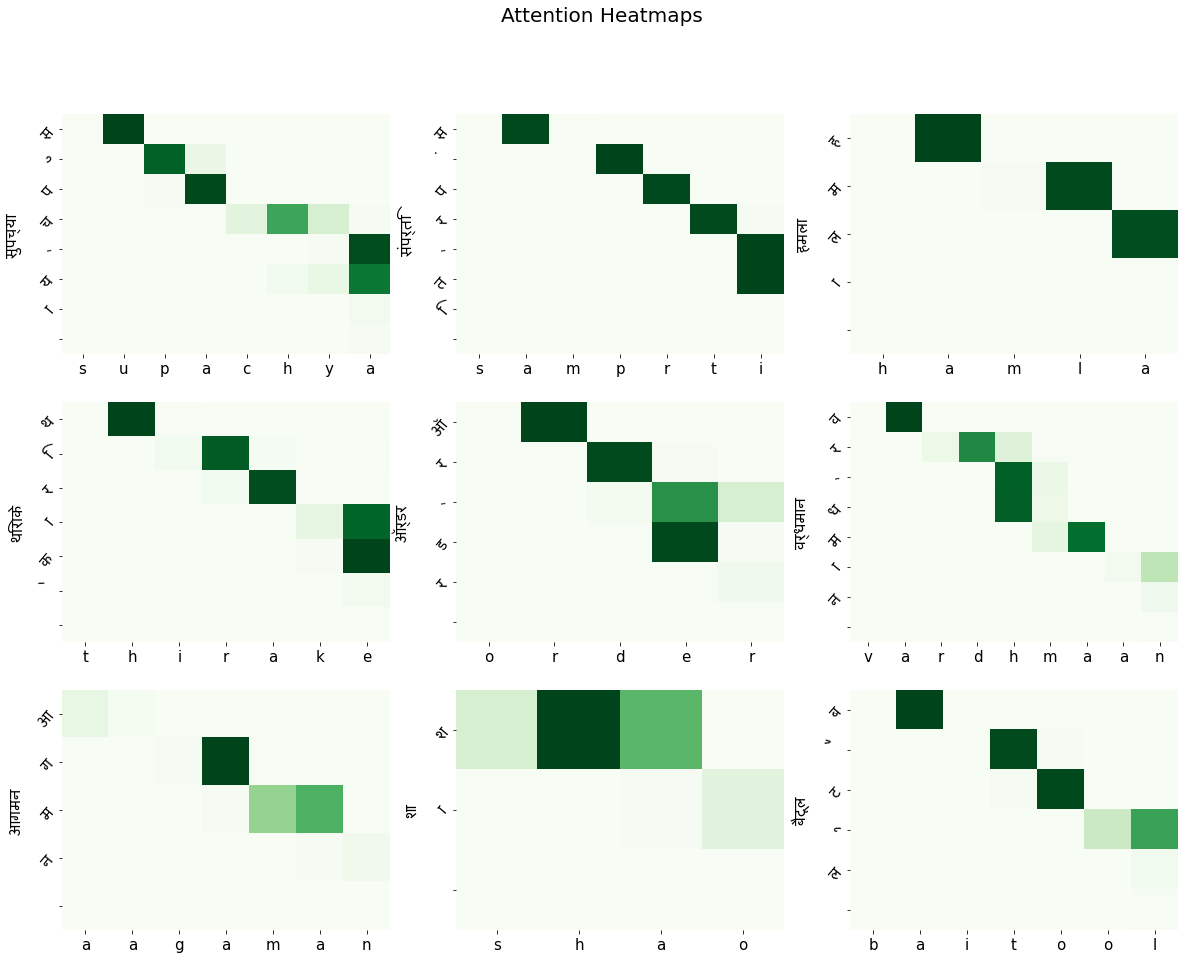

In [ ]:
ttf_path = '/content/MANGAL.TTF'
plot_attention_grid(en_ip_ts_text,en_ip_ts_data,io,pr_obj,ttf_path)

Connectivity

In [ ]:
# Imports for visualisations
from IPython.display import HTML as html_print
from IPython.display import display

In [ ]:
def cstr(s, color='black'):
	if s == ' ':
		return "<text style=color:#000;padding-left:10px;background-color:{}> </text>".format(color, s)
	else:
		return "<text style=color:#000;background-color:{}>{} </text>".format(color, s)
	
# print html
def print_color(t):
  display(html_print(''.join([cstr(ti, color=ci) for ti,ci in t])))

# get appropriate color for value
def get_clr(value):
  colors = ['#85c2e1', '#89c4e2', '#95cae5', '#99cce6', '#a1d0e8'
		'#b2d9ec', '#baddee', '#c2e1f0', '#eff7fb', '#f9e8e8',
		'#f9e8e8', '#f9d4d4', '#f9bdbd', '#f8a8a8', '#f68f8f',
		'#f47676', '#f45f5f', '#f34343', '#f33b3b', '#f42e2e']
  value = int((value * 100) / 5)
  
  return colors[value]

# sigmoid function
def sigmoid(x):
	z = 1/(1 + np.exp(-x)) 
	return z

In [ ]:
def visualize(input_seq,a):
  for i in range(len(char_by_char[:-1])):
    text_colours = []
    print(char_by_char[i])
    for j in range(len(input_seq)):
      text = (input_seq[j], get_clr(a[i][j]))
      text_colours.append(text)
    print_color(text_colours)

In [ ]:
st=3410

In [ ]:
input_seq = en_ip_ts_data[st:st+1]
decoded_sentence,char_by_char,att_mtx = io.decode_sequence(input_seq)
print('Input word:', en_ip_ts_text[st])
#print('Target sentence:', target_test_texts[st])
print('Predicted chars:', char_by_char)
print('Decoded word:', decoded_sentence)
mtx=[]
input_chars = [c for c in en_ip_ts_text[st]]
for i in range(len(char_by_char)):
      output_matrix=(att_mtx[i][0][0][:len(input_chars)])
      output_matrix=sigmoid(output_matrix)
      mtx.append(output_matrix)
a = np.array(mtx)

Input word: raatrichar
Predicted chars: ['र', 'ा', 'त', '्', 'र', 'ि', 'च', 'ा', 'र', '\n']
Decoded word: रात्रिचार



In [ ]:
visualize(en_ip_ts_text[st],a)

र


ा


त


्


र


ि


च


ा


र
